# 02 — ML Embeddings
## BERT Embeddings + Feature Building + Dimensionality Reduction

This notebook generates semantic embeddings (BERT or synthetic), combines them
with structural features into a composite vector, and reduces dimensionality.

Modules used: `bert_embedder.py`, `feature_builder.py`, `dimensionality_reducer.py`

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bert_embedder import BERTEmbedder
from feature_builder import FeatureBuilder
from dimensionality_reducer import DimensionalityReducer

with open(Path.cwd().parent / "output" / "intermediate_01.pkl", "rb") as f:
    data = pickle.load(f)

schema = data["schema"]
preprocessed_texts = data["preprocessed_texts"]
e_type = data["e_type"]
e_rest = data["e_rest"]
e_stat = data["e_stat"]
all_columns = data["all_columns"]
column_index = data["column_index"]

print(f"Loaded: {len(preprocessed_texts)} texts, e_type={e_type.shape}, e_rest={e_rest.shape}")

Loaded: 235 texts, e_type=(235, 12), e_rest=(235, 5)


## 1. BERT Embeddings

Set `SKIP_BERT = True` to use synthetic embeddings (avoids ~1.5GB download).

In [2]:
SKIP_BERT = True  # Change to False for real BERT embeddings

if SKIP_BERT:
    np.random.seed(42)
    e_text = np.random.randn(len(preprocessed_texts), 768).astype(np.float32)
    print("Using SYNTHETIC embeddings (SKIP_BERT=True)")
else:
    embedder = BERTEmbedder()
    e_text = embedder.encode(preprocessed_texts)
    print(f"Using BERT embeddings ({embedder.model_name})")

print(f"Embedding shape: {e_text.shape}")

Using SYNTHETIC embeddings (SKIP_BERT=True)
Embedding shape: (235, 768)


## 2. Table Similarity

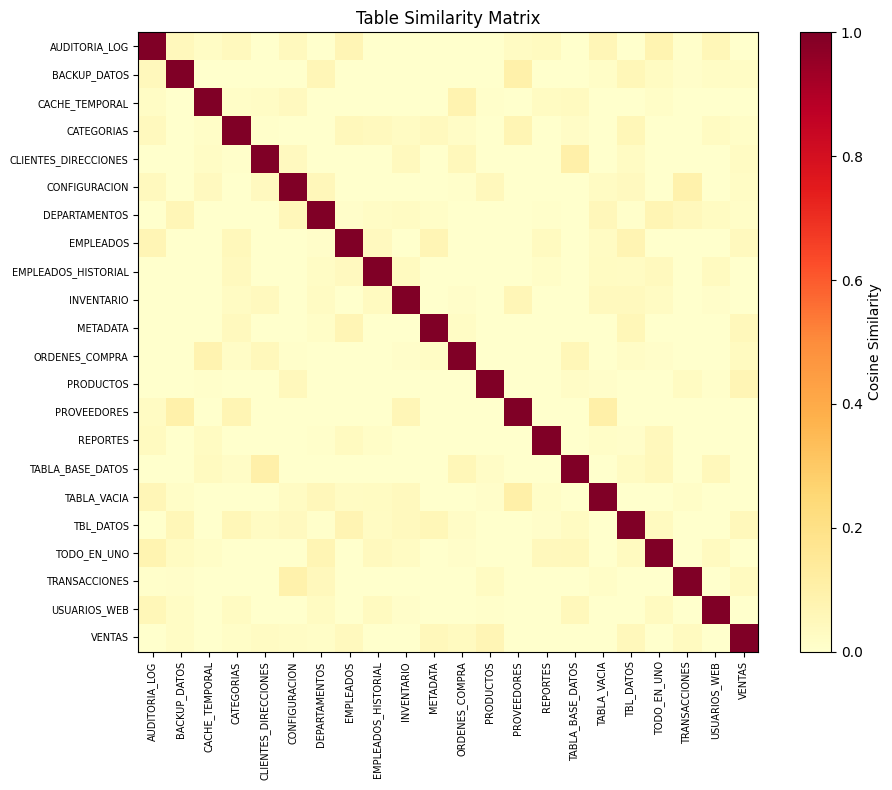

In [3]:
from numpy.linalg import norm

table_vectors = []
table_names = []
for table in schema.tables:
    start = sum(len(t.columns) for t in schema.tables[:schema.tables.index(table)])
    end = start + len(table.columns)
    table_vectors.append(e_text[start:end].mean(axis=0))
    table_names.append(table.name)

table_matrix = np.array(table_vectors)
n_tables = len(table_names)
sim_matrix = np.zeros((n_tables, n_tables))
for i in range(n_tables):
    for j in range(n_tables):
        ni, nj = norm(table_matrix[i]), norm(table_matrix[j])
        if ni > 0 and nj > 0:
            sim_matrix[i, j] = np.dot(table_matrix[i], table_matrix[j]) / (ni * nj)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim_matrix, cmap="YlOrRd", vmin=0, vmax=1)
plt.colorbar(im, label="Cosine Similarity")
ax.set_xticks(range(n_tables))
ax.set_yticks(range(n_tables))
ax.set_xticklabels(table_names, rotation=90, fontsize=7)
ax.set_yticklabels(table_names, fontsize=7)
ax.set_title("Table Similarity Matrix")
plt.tight_layout()
plt.show()

## 3. Build Composite Feature Vector

$$\phi = \alpha \cdot \text{BERT}_{\text{norm}} + \beta \cdot \text{Type}_{\text{norm}} + \gamma \cdot \text{Constraints}_{\text{norm}} + \delta \cdot \text{Stat}_{\text{norm}}$$

Best known weights: alpha=0.35, beta=0.15, gamma=0.50, delta=0.00

In [4]:
builder = FeatureBuilder(alpha=0.35, beta=0.15, gamma=0.50, delta=0.00)
phi = builder.build(e_text, e_type, e_rest, e_stat)

print(f"Composite vector phi shape: {phi.shape}")
print(f"Components: BERT({e_text.shape[1]}) + Types({e_type.shape[1]}) + Constraints({e_rest.shape[1]}) + Stat({e_stat.shape[1]})")

Composite vector phi shape: (235, 786)
Components: BERT(768) + Types(12) + Constraints(5) + Stat(1)


## 4. Dimensionality Reduction

In [5]:
reducer = DimensionalityReducer(method="umap", n_components=5)
X_reduced = reducer.fit_transform(phi)
print(f"Reduced shape: {X_reduced.shape}")

/Users/jesusmarentes/Documents/Documents - MacBook Air de Jesús/db_bad_clust/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/jesusmarentes/Documents/Documents - MacBook Air de Jesús/db_bad_clust/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced shape: (235, 5)


/Users/jesusmarentes/Documents/Documents - MacBook Air de Jesús/db_bad_clust/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


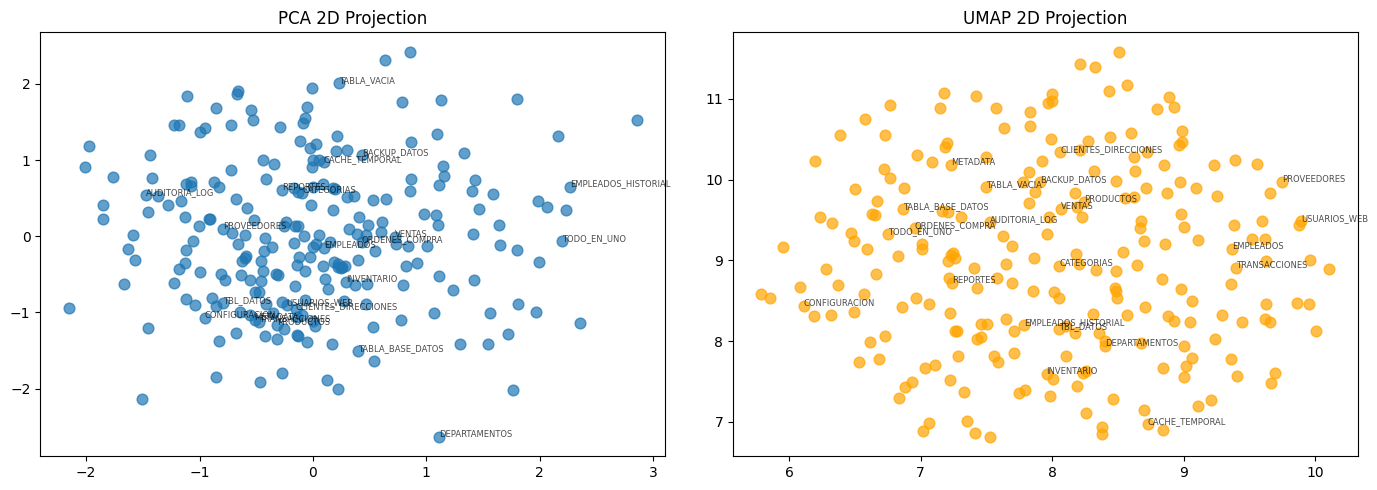

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pca_2d = DimensionalityReducer(method="pca", n_components=2)
X_pca = pca_2d.fit_transform(phi)
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, s=60)
for i, name in enumerate(table_names):
    axes[0].annotate(name, (X_pca[i, 0], X_pca[i, 1]), fontsize=6, alpha=0.7)
axes[0].set_title("PCA 2D Projection")

umap_2d = DimensionalityReducer(method="umap", n_components=2)
X_umap = umap_2d.fit_transform(phi)
axes[1].scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.7, s=60, c="orange")
for i, name in enumerate(table_names):
    axes[1].annotate(name, (X_umap[i, 0], X_umap[i, 1]), fontsize=6, alpha=0.7)
axes[1].set_title("UMAP 2D Projection")

plt.tight_layout()
plt.show()

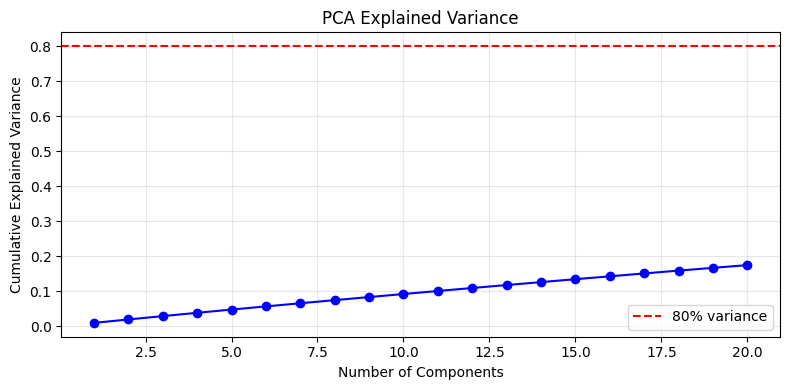

In [7]:
n_test = min(20, phi.shape[1], phi.shape[0])
pca_test = DimensionalityReducer(method="pca", n_components=n_test)
pca_test.fit_transform(phi)

if pca_test.explained_variance_ratio is not None:
    cumvar = np.cumsum(pca_test.explained_variance_ratio)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(1, len(cumvar) + 1), cumvar, "bo-")
    ax.axhline(y=0.80, color="r", linestyle="--", label="80% variance")
    ax.set_xlabel("Number of Components")
    ax.set_ylabel("Cumulative Explained Variance")
    ax.set_title("PCA Explained Variance")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. Save for Notebook 03

In [8]:
intermediate = {
    "X_reduced": X_reduced, "phi": phi,
    "e_text": e_text, "e_type": e_type, "e_rest": e_rest, "e_stat": e_stat,
    "schema": schema, "all_columns": all_columns,
    "table_names": table_names, "column_index": column_index,
}

save_path = Path.cwd().parent / "output" / "intermediate_02.pkl"
with open(save_path, "wb") as f:
    pickle.dump(intermediate, f)

print(f"Saved to {save_path}")
print(f"  X_reduced: {X_reduced.shape}, phi: {phi.shape}")

Saved to /Users/jesusmarentes/Documents/Documents - MacBook Air de Jesús/db_bad_clust/output/intermediate_02.pkl
  X_reduced: (235, 5), phi: (235, 786)
